### MDART PAPER: Fig 4 / SuppFig 7 (NHP Analyses)


In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

import matplotlib as mpl
# Set the fonttype for PDF to be TrueType (42)
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

### Load data

In [2]:
beh_file = '../data/figure4/nec30aln30_t1.xls'

beh_df = pd.read_excel(beh_file, sheet_name=None)

nec30aln30_t1 = pd.DataFrame(columns=['SUBJ', 'PAIR', 'GRP'])

for sheet in beh_df.keys():
    if sheet != 'DOWNLOAD DATA':
        nec30aln30_t1 = nec30aln30_t1.merge(beh_df[sheet].iloc[:12, :15], on=['SUBJ', 'PAIR', 'GRP'], how='outer')

nec30aln30_t1 = nec30aln30_t1[['SUBJ', 'PAIR', 'GRP']+list(nec30aln30_t1.filter(regex='^NE').columns)]
nec30aln30_t1.columns = [col.replace(' ', '_').replace('/','').replace('-', '_').replace('__', '_') for col in nec30aln30_t1.columns]
nec30aln30_t1 = nec30aln30_t1.dropna()

print(nec30aln30_t1.shape)
nec30aln30_t1


(12, 237)


,SUBJ,PAIR,GRP,NEC30A30_T_ALLVOC_NEC1_x,NEC30A30_T_ALLVOC_NEC2,NEC30A30_T_ALLVOC_NEC3,NEC30A30_T_ALLVOC_NEC4,NEC30A30_T_ALLVOC_NEC5,NEC30A30_T_ALLVOC_NEC6,NEC30A30_T_ALLVOC_A1,...,NEC30A30_T_EH_NEC3,NEC30A30_T_EH_NEC4,NEC30A30_T_EH_NEC5,NEC30A30_T_EH_NEC6,NEC30A30_T_ALLEXP_NEC1,NEC30A30_T_ALLEXP_NEC2,NEC30A30_T_ALLEXP_NEC3,NEC30A30_T_ALLEXP_NEC4,NEC30A30_T_ALLEXP_NEC5,NEC30A30_T_ALLEXP_NEC6
0,BK17,1,CON,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,1.821514,1.439333,1.466868,1.703291,1.629410,1.656098
1,BK34,2,EXP,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,1.372912,1.354108,1.530200,1.714330,1.580925,1.262451
2,BK43,1,EXP,0,0,1,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,1.517196,1.113943,1.260071,1.290035,1.276462,1.354108
3,BK45,2,CON,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,1.862131,1.611723,1.651278,1.738781,1.547775,1.619093
4,BK53,3,EXP,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,1.519828,1.691965,1.850646,1.340444,1.857332,1.313867
5,BK67,3,CON,0,0,0,0,0,0,0,...,1.372912,1.071882,1.029384,1.184691,1.496930,1.728354,1.768638,1.436163,1.367356,1.390935
6,BL26,6,EXP,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,1.764176,1.930440,1.941014,1.624282,1.679428,2.007748
7,BL28,6,CON,0,0,0,0,0,0,0,...,0.000000,0.000000,0.301030,0.322219,1.843233,1.551450,1.403121,1.285557,1.594393,1.491362
8,BL47,7,CON,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,1.217484,1.365488,1.017033,1.303196,1.198657,1.646404
9,BL60,7,EXP,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,1.361728,1.454845,1.240549,1.414973,1.463893,1.629410


In [3]:
beh_file = '../data/figure4/nec30aln30_t2.xls'

beh_df = pd.read_excel(beh_file, sheet_name=None)

# Data-quality fix: every sheet in this file has its first timepoint column
# (NEC1) mislabeled as 'N30A30-2-ALLVOC-NEC1', a copy-paste artifact from
# using the ALLVOC sheet as a template for the others. The underlying values
# are genuine per-behavior data (confirmed against raw values), so restore
# the correct per-behavior column name before merging -- otherwise every
# sheet collides on this one shared column name and the merge fails, and
# each behavior silently loses its NEC1 timepoint.
for sheet, df in beh_df.items():
    behavior = sheet[:-1]  # e.g. 'VVT' -> 'VV', 'ALLOCT' -> 'ALLOC'
    mislabeled_col = 'N30A30-2-ALLVOC-NEC1'
    correct_col = f'N30A30-2-{behavior}-NEC1'
    if mislabeled_col in df.columns and mislabeled_col != correct_col:
        beh_df[sheet] = df.rename(columns={mislabeled_col: correct_col})

nec30aln30_t2 = pd.DataFrame(columns=['SUBJ', 'PAIR', 'GRP'])

for sheet in beh_df.keys():
    nec30aln30_t2 = nec30aln30_t2.merge(beh_df[sheet], on=['SUBJ', 'PAIR', 'GRP'], how='outer')

print('done')
nec30aln30_t2.columns = [col.replace(' ', '_').replace('/','').replace('-', '_').replace('__', '_') for col in nec30aln30_t2.columns]
nec30aln30_t2 = nec30aln30_t2.dropna()

print(nec30aln30_t2.shape)
nec30aln30_t2


done
(10, 267)


,SUBJ,PAIR,GRP,N30A30_2_ALLVOC_NEC1,N30A30_2_ALLVOC_NEC2,N30A30_2_ALLVOC_NEC3,N30A30_2_ALLVOC_NEC4,N30A30_2_ALLVOC_NEC5,N30A30_2_ALLVOC_NEC6,N30A30_2_ALLVOC_A1,...,N30A30_2_ALLEXP_NEC3,N30A30_2_ALLEXP_NEC4,N30A30_2_ALLEXP_NEC5,N30A30_2_ALLEXP_NEC6,N30A30_2_ALLEXP_A1,N30A30_2_ALLEXP_A2,N30A30_2_ALLEXP_A3,N30A30_2_ALLEXP_A4,N30A30_2_ALLEXP_A5,N30A30_2_ALLEXP_A6
0,BK34,2,EXP,0,0,0,0.000000,0.000000,0.000000,0.000000,...,1.629410,1.544068,1.808886,1.781755,0,0,0,0,0,0
1,BK45,2,CON,0,0,0,0.000000,0.000000,0.000000,0.000000,...,1.683947,1.926342,1.857935,1.550228,0,0,0,0,0,0
2,BK53,3,EXP,0,0,0,0.000000,0.000000,0.000000,0.000000,...,1.290035,1.666518,1.184691,1.636488,0,0,0,0,0,0
3,BK67,3,CON,0,0,4,4.358899,3.464102,2.828427,1.732051,...,1.466868,1.399674,1.232996,1.513218,0,0,0,0,0,0
4,BL26,6,EXP,0,0,0,0.000000,0.000000,0.000000,0.000000,...,1.995635,2.163161,2.089905,1.889862,0,0,0,0,0,0
5,BL28,6,CON,0,0,0,0.000000,1.000000,0.000000,0.000000,...,1.287802,1.565848,0.681241,0.838849,0,0,0,0,0,0
6,BL47,7,CON,0,0,0,0.000000,0.000000,0.000000,0.000000,...,1.882525,1.729974,1.570543,1.988559,0,0,0,0,0,0
7,BL60,7,EXP,0,0,0,0.000000,0.000000,0.000000,0.000000,...,1.821514,1.872156,1.107210,1.501059,0,0,0,0,0,0
8,r14086,5,EXP,0,0,0,0.000000,0.000000,0.000000,0.000000,...,1.580925,1.421604,1.606381,1.481443,0,0,0,0,0,0
9,r14107,5,CON,0,0,0,0.000000,0.000000,0.000000,0.000000,...,1.778151,1.604226,1.454845,1.619093,0,0,0,0,0,0


#### Pre and post lesion freezing

In [4]:
beh_file = '../data/figure4/upet.xls'

beh_df = pd.read_excel(beh_file, sheet_name=None)

upet = pd.DataFrame(columns=['SUBJ', 'PAIR', 'GRP'])
for sheet in beh_df.keys():
    upet = upet.merge(beh_df[sheet], on=['SUBJ', 'PAIR', 'GRP'], how='outer')

upet.columns = [col.replace(' ', '_').replace('-', '_').replace('__', '_').replace('µ', 'u') for col in upet.columns]
upet = upet.dropna()

upet

,SUBJ,PAIR,GRP,uPET_ALLVOC_NEC1_PRE,uPET_ALLVOC_NEC2_PRE,uPET_ALLVOC_NEC3_PRE,uPET_ALLVOC_NEC4_PRE,uPET_ALLVOC_NEC5_PRE,uPET_ALLVOC_NEC6_PRE,uPET_ALLVOC_NEC1_POST1,...,uPET_ALLEXP_NEC3_PRE,uPET_ALLEXP_NEC4_PRE,uPET_ALLEXP_NEC5_PRE,uPET_ALLEXP_NEC6_PRE,uPET_ALLEXP_NEC1_POST1,uPET_ALLEXP_NEC2_POST1,uPET_ALLEXP_NEC3_POST1,uPET_ALLEXP_NEC4_POST1,uPET_ALLEXP_NEC5_POST1,uPET_ALLEXP_NEC6_POST1
0,BK17,1,CON,0,0.000000,0.00000,0.000000,0.000000,0.000000,0,...,1.089905,1.639486,1.176091,1.611723,1.737193,1.567026,1.613842,1.481443,1.499687,1.315970
1,BK34,2,EXP,0,0.000000,0.00000,3.162278,4.242641,4.242641,0,...,1.338456,1.276462,1.285557,1.033424,1.761176,1.440909,1.274158,1.555094,1.357935,1.336460
2,BK43,1,EXP,0,0.000000,0.00000,1.000000,0.000000,0.000000,0,...,1.557507,1.576341,1.283301,1.434569,1.453318,1.444045,1.383815,1.334454,1.222716,1.093422
3,BK45,2,CON,0,0.000000,0.00000,0.000000,0.000000,2.000000,0,...,1.350248,1.209515,1.214844,1.245513,1.846955,2.079181,1.745855,1.967080,1.495544,2.077731
4,BK53,3,EXP,0,0.000000,0.00000,0.000000,0.000000,0.000000,0,...,1.556303,1.462398,1.557507,1.535294,1.498311,1.603144,1.608526,1.318063,1.932981,1.895975
5,BK67,3,CON,0,0.000000,0.00000,0.000000,0.000000,0.000000,0,...,1.468347,1.469822,1.008600,1.465383,1.662758,1.404834,1.344392,1.107210,2.260548,1.305351
6,BL16,4,CON,0,0.000000,1.00000,3.316625,6.082763,6.324555,0,...,1.498311,1.814913,1.671173,1.127105,1.786041,1.634477,1.247973,1.494155,1.313867,1.784617
7,BL19,4,EXP,0,0.000000,0.00000,0.000000,1.000000,0.000000,0,...,1.340444,1.383815,1.037426,1.423246,1.730782,1.569374,1.712650,1.674861,1.641474,1.594393
8,BL26,6,EXP,0,0.000000,0.00000,0.000000,0.000000,0.000000,0,...,1.350248,1.552668,1.421604,1.181844,1.761928,1.705864,1.820201,1.629410,1.625312,1.372912
9,BL28,6,CON,0,0.000000,0.00000,1.414214,2.828427,4.123106,0,...,1.445604,1.751279,1.762679,1.419956,1.783904,1.468347,1.181844,1.570543,1.668386,1.881385


#### Novel Conspecific

In [5]:
beh_file = '../data/figure4/novel.xls'
beh_df = pd.read_excel(beh_file, sheet_name=None)

novel = pd.DataFrame(columns=['SUBJ', 'PAIR', 'GRP'])
for sheet in beh_df.keys():
    novel = novel.merge(beh_df[sheet], on=['SUBJ', 'PAIR', 'GRP'], how='outer')

novel.columns = [col.replace(' ', '_').replace('-', '_').replace('__', '_') for col in novel.columns]
novel = novel.dropna()

novel.columns.values

array(['SUBJ', 'PAIR', 'GRP', 'NOVEL_ALLVOC_S1', 'NOVEL_ALLVOC_S2',
       'NOVEL_ALLVOC_S3', 'NOVEL_ALLVOC_S4', 'NOVEL_ALLVOC_S5',
       'NOVEL_ALLVOC_S6', 'NOVEL_VV_S1', 'NOVEL_VV_S2', 'NOVEL_VV_S3',
       'NOVEL_VV_S4', 'NOVEL_VV_S5', 'NOVEL_VV_S6', 'NOVEL_BA_S1',
       'NOVEL_BA_S2', 'NOVEL_BA_S3', 'NOVEL_BA_S4', 'NOVEL_BA_S5',
       'NOVEL_BA_S6', 'NOVEL_VO_S1', 'NOVEL_VO_S2', 'NOVEL_VO_S3',
       'NOVEL_VO_S4', 'NOVEL_VO_S5', 'NOVEL_VO_S6', 'NOVEL_GI_S1',
       'NOVEL_GI_S2', 'NOVEL_GI_S3', 'NOVEL_GI_S4', 'NOVEL_GI_S5',
       'NOVEL_GI_S6', 'NOVEL_SH_S1', 'NOVEL_SH_S2', 'NOVEL_SH_S3',
       'NOVEL_SH_S4', 'NOVEL_SH_S5', 'NOVEL_SH_S6', 'NOVEL_ALLOC_S1',
       'NOVEL_ALLOC_S2', 'NOVEL_ALLOC_S3', 'NOVEL_ALLOC_S4',
       'NOVEL_ALLOC_S5', 'NOVEL_ALLOC_S6', 'NOVEL_LO_S1', 'NOVEL_LO_S2',
       'NOVEL_LO_S3', 'NOVEL_LO_S4', 'NOVEL_LO_S5', 'NOVEL_LO_S6',
       'NOVEL_LOST_S1', 'NOVEL_LOST_S2', 'NOVEL_LOST_S3', 'NOVEL_LOST_S4',
       'NOVEL_LOST_S5', 'NOVEL_LOST_S6', 'NOVEL_I

In [6]:
MY_PALETTE=["#516E93", "#b14e9d"]

# Output path: edit for your own system/data layout
OUTPUT_DIR = r"C:\Users\psiok\Box\3.Projects\3.MDART-Paper\MDART_Analyses\outputs\figures"

In [7]:
## Helper functions for plotting

def stars_from_pval(p):
    if p < 0.0001:
            return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return 'n.s.'

def add_sig_bracket(ax, x1, x2, pval, y=None, gap_frac=0.06,
                     color='black', linewidth=0.4, fontsize=6, label=None):
    # y defaults to just above whatever is already plotted on ax (bars,
    # errorbars, swarm points), so this works regardless of the panel's scale.
    ylo, yhi = ax.get_ylim()
    rng = (yhi - ylo) or 1.0

    if y is None:
        y = ax.dataLim.y1 + gap_frac * rng

    ax.plot([x1, x2], [y, y], lw=linewidth, color=color, clip_on=False)
    ax.text((x1 + x2) / 2, y, label if label is not None else stars_from_pval(pval), ha='center', va='bottom',
            fontsize=fontsize, color=color)

    top = y + gap_frac * rng
    if top > yhi:
        ax.set_ylim(ylo, top)

    return y


### Fig 4e, 4g — HIP-Persistence (NEC30-ALN30) paradigm

`nec_aln_plot_with_diff` produces two panels per call:
- left: mean behavior across 5-min bins during NEC and ALN-following-NEC (Fig4e / SFig4a)
- right: ALN-NEC difference, individual animals marked by BST-overlap quality
  (diamond=bilateral, circle=unilateral, square=no overlap), matching Fig4f (Fig4g / SFig4b / SFig4e)


In [8]:
def nec_aln_plot_with_diff(df, beh='FF', beh_label='Freezing', beh_units='log seconds',
                           beh_regex_str='_A[1|2|4]', id_vars=['SUBJ', 'GRP', 'PAIR'],
                           order=None, hue_order=None,
                           unilateral_lesion=['r14086', 'BK43', 'BL19'],
                           no_lesion=['BK53'],
                           timecourse_figsize=(4.8, 2.5),
                           diff_figsize=(1.5, 2.5)):

    subj_to_drop = unilateral_lesion+no_lesion

    regex_str = '|'.join(id_vars)
    beh_regex=beh+beh_regex_str
    beh_val = beh_label
    this_beh_df = pd.melt( df.filter(regex=regex_str+'|'+beh_regex),
        id_vars=id_vars,
        value_vars=df.filter(regex=beh_regex),
        var_name=beh,
        value_name=beh_val)

    this_beh_df['cond_str'] = this_beh_df[beh].str.split('_').str[-1]
    this_beh_df = this_beh_df[this_beh_df['cond_str']!='diff']
    this_beh_df = this_beh_df[this_beh_df['cond_str']!='mean']
    this_beh_df['TIME'] = [int(s[-1]) for s in this_beh_df['cond_str']]
    this_beh_df['COND'] = [s[:-1] for s in this_beh_df['cond_str']]
    this_beh_df['COND_TIME'] = [row['COND']+str(row['TIME']) for i, row in this_beh_df.iterrows()]
    this_beh_df['Cond_num'] = this_beh_df['COND'].replace({'A': 1, 'N': 2, 'S': 3})
    this_beh_df['TEST_NUM'] = [s[-1] for s in this_beh_df[beh].str.split('_').str[0]]

    m = smf.mixedlm(f'{beh_val} ~ C(GRP) * C(COND) + TIME', data=this_beh_df.dropna(), groups='PAIR').fit()
    print( f'MixedLM {beh_label}: '
       f'Group: z={m.tvalues["C(GRP)[T.EXP]"]:.2f}, P={m.pvalues["C(GRP)[T.EXP]"]:.4f}; '
       f'Cond: z={m.tvalues["C(COND)[T.NEC]"]:.2f}, P={m.pvalues["C(COND)[T.NEC]"]:.4f}; '
       f'GroupByCond: z={m.tvalues["C(GRP)[T.EXP]:C(COND)[T.NEC]"]:.2f}, P={m.pvalues["C(GRP)[T.EXP]:C(COND)[T.NEC]"]:.4f}' )
    p_groupXcond_full = m.pvalues["C(GRP)[T.EXP]:C(COND)[T.NEC]"]

    names = m.model.exog_names
    contrast = np.zeros((1, len(names)))
    contrast[0, names.index('C(GRP)[T.EXP]')] = 1
    contrast[0, names.index('C(GRP)[T.EXP]:C(COND)[T.NEC]')] = 1

    simple_nec = m.t_test(contrast)
    print(f'Group effect within NEC: z={simple_nec.tvalue[0][0]:.2f}, P={simple_nec.pvalue:.4f}')

    if subj_to_drop is not None:
        m_drop = smf.mixedlm(f'{beh_val} ~ C(GRP) * C(COND) + TIME', data=this_beh_df[~this_beh_df['SUBJ'].isin(subj_to_drop)].dropna(), groups='PAIR').fit()
        print( f'DROP -- MixedLM {beh_label}: '
           f'Group: z={m_drop.tvalues["C(GRP)[T.EXP]"]:.2f}, P={m_drop.pvalues["C(GRP)[T.EXP]"]:.4f}; '
           f'Cond: z={m_drop.tvalues["C(COND)[T.NEC]"]:.2f}, P={m_drop.pvalues["C(COND)[T.NEC]"]:.4f}; '
           f'GroupByCond: z={m_drop.tvalues["C(GRP)[T.EXP]:C(COND)[T.NEC]"]:.2f}, P={m_drop.pvalues["C(GRP)[T.EXP]:C(COND)[T.NEC]"]:.4f}' )
        p_groupXcond_sub = m_drop.pvalues["C(GRP)[T.EXP]:C(COND)[T.NEC]"]

        names_drop = m_drop.model.exog_names
        contrast_drop = np.zeros((1, len(names_drop)))
        contrast_drop[0, names_drop.index('C(GRP)[T.EXP]')] = 1
        contrast_drop[0, names_drop.index('C(GRP)[T.EXP]:C(COND)[T.NEC]')] = 1

        simple_nec_drop = m_drop.t_test(contrast_drop)
        print(f'DROP -- Group effect within NEC: z={simple_nec_drop.tvalue[0][0]:.2f}, P={simple_nec_drop.pvalue:.4f}')

        this_beh_df['Lesion_vs_CtrlAndDrop'] = (~this_beh_df['SUBJ'].isin(subj_to_drop)) & (this_beh_df['GRP']=='EXP')
        m = smf.mixedlm(f'{beh_val} ~ C(Lesion_vs_CtrlAndDrop) * C(COND) + TIME', data=this_beh_df, groups='PAIR' ).fit()
        print( f'EXP vs. Ctrl & Drop -- MixedLM {beh_label}: Group={m.pvalues["C(Lesion_vs_CtrlAndDrop)[T.True]"]}, Cond={m.pvalues["C(COND)[T.NEC]"]}, GroupByCond={m.pvalues["C(Lesion_vs_CtrlAndDrop)[T.True]:C(COND)[T.NEC]"]}' )

    #### FIGURE 1 -- timecourse (own figure, own size)

    f1, ax1 = plt.subplots(1, 1, figsize=timecourse_figsize)

    sns.pointplot( data=this_beh_df, x='COND_TIME', y=beh_val, hue='GRP', ax=ax1, errorbar=('se', 1),
                   hue_order=hue_order, palette=MY_PALETTE, linewidth=0.8, markersize=0.8 * 3,
                   err_kws={'linewidth': 0.6} )
    sns.lineplot( data=this_beh_df[this_beh_df['GRP']=='CON'], x='COND_TIME', y=beh_val, hue='SUBJ', ax=ax1,
                  palette=[MY_PALETTE[0]]*len( this_beh_df[this_beh_df['GRP']=='CON']['SUBJ'].unique()),
                  alpha=.1, legend=False, linewidth=0.4)
    sns.lineplot( data=this_beh_df[this_beh_df['GRP']=='EXP'], x='COND_TIME', y=beh_val, hue='SUBJ', ax=ax1,
                  palette=[MY_PALETTE[1]]*len( this_beh_df[this_beh_df['GRP']=='EXP']['SUBJ'].unique()),
                  alpha=.1, legend=False, linewidth=0.4)

    # ax1.vlines(x=5.5, ymin=ax1.get_ylim()[0], ymax=ax1.get_ylim()[1], color='k', linestyles='--', alpha=.3)
    ax1.vlines(x=5.5, ymin=ax1.get_ylim()[0], ymax=ax1.get_ylim()[1], color='k', linestyles='--', alpha=.3, linewidth=1)

    ax1.set_ylim(-0.1, 2.5)
    ax1.set_yticks(np.arange(0, 2.5 + 0.5, 0.5))
    x_ticks = ax1.get_xticks()
    x_labels = [str(((x%6)+1)*5) for x in x_ticks]
    ax1.set_xticks(x_ticks, x_labels)

    sec = ax1.secondary_xaxis(location=0)
    sec.set_xticks([2.5, 8.5], labels=['\nNEC (5-min)', '\nALN (5-min)'], fontsize=6)
    sec.tick_params(length=0)
    sec.spines['bottom'].set_visible(False)
    ax1.set_xlabel('', fontsize= 6, fontfamily= 'arial', labelpad= 1)
    ax1.set_ylabel(f'{beh_label}\n({beh_units})', fontsize= 6, fontfamily= 'arial', labelpad= 1)

    ax1.tick_params(axis='both', labelsize= 5.8, pad= 0.5, width= 0.4)
    ax1.spines['left'].set_linewidth( 0.4)
    ax1.spines['bottom'].set_linewidth( 0.4)

    if ax1.get_legend() is not None:
        ax1.legend(fontsize=5, title='GRP', title_fontsize=5, labelspacing=0.2)

    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    beh_val = beh_val+'_NECvsALN'

    this_beh_df_a = this_beh_df[ this_beh_df['COND']=='A' ]
    this_beh_df_n = this_beh_df[this_beh_df['COND'] =='NEC'].drop(['GRP','PAIR'], axis=1)

    this_beh_df_an = this_beh_df_a.merge(this_beh_df_n, how='inner', on=['SUBJ', 'TIME'], suffixes=['_a','_nec'])
    this_beh_df_an['beh_NECvsALN'] = this_beh_df_an[f'{beh_label}_a']-this_beh_df_an[f'{beh_label}_nec']

    this_beh_df_an = this_beh_df_an.groupby(['SUBJ', 'GRP','PAIR']).mean(numeric_only=True).reset_index()

    if subj_to_drop is not None:
        this_beh_df_an['high_quality_lesion'] = ((~this_beh_df_an['SUBJ'].isin(subj_to_drop)) & (this_beh_df['GRP']=='EXP')).astype(int)
        this_beh_df_an['unilateral_lesion'] =  ((this_beh_df_an['SUBJ'].isin(unilateral_lesion)) & (this_beh_df['GRP']=='EXP')).astype(int)
        this_beh_df_an['low_quality_lesion'] = ((this_beh_df_an['SUBJ'].isin(no_lesion)) & (this_beh_df['GRP']=='EXP')).astype(int)
        this_beh_df_an['control'] = (this_beh_df['GRP']!='EXP').astype(int)
    else:
        this_beh_df_an['high_quality_lesion'] = 1
        this_beh_df_an['unilateral_lesion'] = 0
        this_beh_df_an['low_quality_lesion'] = 0
        this_beh_df_an['control'] = (this_beh_df['GRP']!='EXP').astype(int)

    m = smf.ols('beh_NECvsALN ~ C(GRP) + C(PAIR)', data=this_beh_df_an).fit()
    print(f'NECvsALN {beh_label}: t({m.df_resid:.0f})={m.tvalues["C(GRP)[T.EXP]"]:.2f}, P={m.pvalues["C(GRP)[T.EXP]"]:.4f}')

    diff_stats = {'p_group_full': m.pvalues['C(GRP)[T.EXP]'], 'p_groupXcond_full': p_groupXcond_full}

    if subj_to_drop is not None:
        m_drop = smf.ols('beh_NECvsALN ~ C(GRP) + C(PAIR)', data=this_beh_df_an[~this_beh_df_an['SUBJ'].isin(subj_to_drop)]).fit()
        print(f'DROP -- NECvsALN {beh_label}: t({m_drop.df_resid:.0f})={m_drop.tvalues["C(GRP)[T.EXP]"]:.2f}, P={m_drop.pvalues["C(GRP)[T.EXP]"]:.4f}')
        diff_stats['p_group_sub'] = m_drop.pvalues['C(GRP)[T.EXP]']
        diff_stats['p_groupXcond_sub'] = p_groupXcond_sub

    #### FIGURE 2 -- ALN-NEC difference (own figure, own size)
    f2, ax2 = plt.subplots(1, 1, figsize=diff_figsize)

    sns.barplot(x='GRP', y='beh_NECvsALN', hue='GRP', data=this_beh_df_an, errorbar=('se', 1), hue_order=hue_order, order=hue_order, ax=ax2, palette=MY_PALETTE, linewidth=0.4, capsize=0.1, err_kws={'linewidth': 0.4}, legend=True)
    sns.swarmplot(x='GRP', y='beh_NECvsALN', hue='GRP', data=this_beh_df_an[this_beh_df_an['high_quality_lesion']==1], hue_order=hue_order, order=hue_order, ax=ax2, palette=MY_PALETTE, marker="D", size=3, edgecolor="white", linewidth=0.4, legend=False)
    sns.swarmplot(x='GRP', y='beh_NECvsALN', hue='GRP', data=this_beh_df_an[this_beh_df_an['control']==1], hue_order=hue_order, order=hue_order, ax=ax2, palette=MY_PALETTE, marker="o", size=3, edgecolor="white", linewidth=0.4, legend=False)
    sns.swarmplot(x='GRP', y='beh_NECvsALN', hue='GRP', data=this_beh_df_an[this_beh_df_an['unilateral_lesion']==1], hue_order=hue_order, order=hue_order, ax=ax2, palette=MY_PALETTE, marker="o", size=3, edgecolor="white", linewidth=0.4, legend=False)
    sns.swarmplot(x='GRP', y='beh_NECvsALN', hue='GRP', data=this_beh_df_an[this_beh_df_an['low_quality_lesion']==1], hue_order=hue_order, order=hue_order, ax=ax2, palette=MY_PALETTE, marker="s", size=3, edgecolor="white", linewidth=0.4, legend=False)

    ax2.set_xlabel('GRP', fontsize=6, fontfamily='arial', labelpad=1)
    ax2.set_ylabel(f'ALN - NEC {beh_label}\n(difference in {beh_units})', fontsize=6, fontfamily='arial', labelpad=1)

    ax2.tick_params(axis='both', labelsize=5.8, pad=0.5, width=0.4)
    ax2.spines['left'].set_linewidth(0.4)
    ax2.spines['bottom'].set_linewidth(0.4)

    if ax2.get_legend() is not None:
        ax2.legend(fontsize=5, title='GRP', title_fontsize=5, labelspacing=0.3)

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    return ax1, ax2, diff_stats

MixedLM Freezing: Group: z=-3.14, P=0.0017; Cond: z=0.90, P=0.3689; GroupByCond: z=2.15, P=0.0314
Group effect within NEC: z=-0.10, P=0.9204
DROP -- MixedLM Freezing: Group: z=-6.16, P=0.0000; Cond: z=1.00, P=0.3173; GroupByCond: z=4.04, P=0.0001
DROP -- Group effect within NEC: z=-0.84, P=0.4023
EXP vs. Ctrl & Drop -- MixedLM Freezing: Group=2.812050262390182e-10, Cond=0.2624881128856721, GroupByCond=1.757598937587461e-05
NECvsALN Freezing: t(5)=-2.29, P=0.0708
DROP -- NECvsALN Freezing: t(2)=-5.74, P=0.0290


C:\Users\psiok\AppData\Local\Temp\ipykernel_19500\3136894108.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(


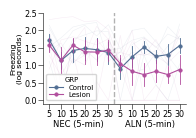

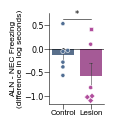

In [9]:
MM_TO_INCH = 1 / 25.4

timecourse_figsize = (47 * MM_TO_INCH, 30 * MM_TO_INCH)  # 48mm x 30mm -> (1.890, 1.181) inches
diff_bar_figsize = (18 * MM_TO_INCH, 30 * MM_TO_INCH)
ax1, ax2, diff_stats = nec_aln_plot_with_diff(
    nec30aln30_t1, beh='FF', beh_label='Freezing', beh_units='log seconds',
    beh_regex_str='_', order=['NEC','A'], hue_order=['CON','EXP'],
    timecourse_figsize=timecourse_figsize, diff_figsize=diff_bar_figsize
)

# --- Fig4e/4g-only label updates (post-processing, not inside
# nec_aln_plot_with_diff, since that function is shared with SFig panels
# that haven't been asked for this change) ---
group_labels = {'CON': 'Control', 'EXP': 'Lesion'}

# Panel e: relabel legend entries
if ax1.get_legend() is not None:
    for txt in ax1.get_legend().get_texts():
        txt.set_text(group_labels.get(txt.get_text(), txt.get_text()))

# Panel g: no legend, no "GRP" x-axis label, x-ticks relabeled,
# zero-difference reference line matching the axis linewidth (0.4)
if ax2.get_legend() is not None:
    ax2.get_legend().remove() 
ax2.set_xlabel('')
ax2.set_xticklabels(
    [group_labels.get(t.get_text(), t.get_text()) for t in ax2.get_xticklabels()],
    fontsize=5.8, fontfamily='arial',
)
ax2.axhline(0, color='black', linewidth=0.4)
add_sig_bracket(ax2, x1=0, x2=1, pval=diff_stats['p_groupXcond_full'])

# ax1.set_title('NEC30-ALN30', fontsize=6, fontfamily='arial', p ad=1)
# ax1.figure.savefig('Fig4_e_HIP_persistence_freezing_timecourse.pdf', bbox_inches='tight', transparent=True)
ax2.figure.savefig(os.path.join(OUTPUT_DIR, 'Fig4_g_HIP_persistence_freezing_diff_with_p_value.pdf'), bbox_inches='tight')

### Fig 4i — Social Interaction (Novel Conspecific) paradigm

`one_condition_plot` produces a single bar+swarm panel comparing BST-lesioned
vs. control across the 30-min interaction, with the same marker scheme for
BST-overlap quality.

In [10]:
def one_condition_plot(df, beh='FF', beh_label='Freezing', beh_units='log seconds',
                       beh_regex_str='_A[1|2|4]', id_vars=['SUBJ', 'GRP', 'PAIR'],
                       order=None, hue_order=None,
                       unilateral_lesion=['r14086', 'BK43', 'BL19'],
                       no_lesion=['BK53'],
                       separate_x_by_group=False):

    subj_to_drop = unilateral_lesion+no_lesion

    regex_str = '|'.join(id_vars)
    beh_regex=beh+beh_regex_str
    beh_val = 'logFF'
    this_beh_df = pd.melt( df.filter(regex=regex_str+'|'+beh_regex),
        id_vars=id_vars,
        value_vars=df.filter(regex=beh_regex),
        var_name=beh,
        value_name=beh_val)

    this_beh_df['cond_str'] = this_beh_df[beh].str.split('_').str[-1]
    this_beh_df = this_beh_df[this_beh_df['cond_str']!='diff']
    this_beh_df = this_beh_df[this_beh_df['cond_str']!='mean']
    this_beh_df['TIME'] = [int(s[-1]) for s in this_beh_df['cond_str']]
    this_beh_df['COND'] = [s[:-1] for s in this_beh_df['cond_str']]
    this_beh_df['COND_TIME'] = [row['COND']+str(row['TIME']) for i, row in this_beh_df.iterrows()]
    this_beh_df['Cond_num'] = this_beh_df['COND'].replace({'A': 1, 'N': 2, 'S': 3})
    this_beh_df['TEST_NUM'] = [s[-1] for s in this_beh_df[beh].str.split('_').str[0]]

    this_beh_noTime_df = this_beh_df.groupby(['COND', 'SUBJ', 'GRP','PAIR' ])[beh_val].mean().reset_index()

    #### SET FIGURE
    if len(this_beh_noTime_df['COND'].unique()) == 1:
        f, ax = plt.subplots(1,1,figsize=(1,3) )
        m = smf.mixedlm(f'{beh_val} ~ C(GRP) + TIME', data=this_beh_df.dropna(), groups='PAIR').fit()
        if subj_to_drop is not None:
            m_drop = smf.mixedlm(f'{beh_val} ~ C(GRP) + TIME', data=this_beh_df[~this_beh_df['SUBJ'].isin(subj_to_drop)].dropna(), groups='PAIR').fit()
            this_beh_df['high_quality_lesion'] = (~this_beh_df['SUBJ'].isin(subj_to_drop)) & (this_beh_df['GRP']=='EXP')
            m_high_quality_vs_other = smf.mixedlm( f'{beh_val} ~ C(high_quality_lesion)*C(COND) + TIME', this_beh_df.dropna(), groups='PAIR').fit()

    else:
        f, ax = plt.subplots(1,1,figsize=(1.75,2.5) )
        m = smf.mixedlm(f'{beh_val} ~ C(GRP)*C(COND) + TIME', data=this_beh_df.dropna(), groups='PAIR').fit()
        if subj_to_drop is not None:
            m_drop = smf.mixedlm(f'{beh_val} ~ C(GRP)*C(COND) + TIME', data=this_beh_df[~this_beh_df['SUBJ'].isin(subj_to_drop)].dropna(), groups='PAIR').fit()
            this_beh_df['high_quality_lesion'] = (~this_beh_df['SUBJ'].isin(subj_to_drop)) & (this_beh_df['GRP']=='EXP')
            this_beh_df['unilateral_lesion'] = (this_beh_df['SUBJ'].isin(unilateral_lesion)) & (this_beh_df['GRP']=='EXP')
            this_beh_df['low_quality_lesion'] = (this_beh_df['SUBJ'].isin(no_lesion)) & (this_beh_df['GRP']=='EXP')

            m_high_quality_vs_other = smf.mixedlm( f'{beh_val} ~ C(high_quality_lesion)*C(COND) + TIME', this_beh_df.dropna(), groups='PAIR').fit()
            display(m_high_quality_vs_other.summary())

    print(f'{beh_val}: Group: z={m.tvalues["C(GRP)[T.EXP]"]:.2f}, P={m.pvalues["C(GRP)[T.EXP]"]:.4f}')

    group_stats = {'p_group_full': m.pvalues['C(GRP)[T.EXP]']}

    if subj_to_drop is not None:
        print(f'DROP -- {beh_val}: Group: z={m_drop.tvalues["C(GRP)[T.EXP]"]:.2f}, P={m_drop.pvalues["C(GRP)[T.EXP]"]:.4f}')
        print(f'HIGH-QUALITY -- {beh_val}: Group: z={m_high_quality_vs_other.tvalues["C(high_quality_lesion)[T.True]"]:.2f}, P={m_high_quality_vs_other.pvalues["C(high_quality_lesion)[T.True]"]:.4f}')
        group_stats['p_group_sub'] = m_drop.pvalues['C(GRP)[T.EXP]']

    if subj_to_drop is not None:
        this_beh_noTime_df['high_quality_lesion'] = ((~this_beh_noTime_df['SUBJ'].isin(subj_to_drop)) & (this_beh_noTime_df['GRP']=='EXP')).astype(int)
        this_beh_noTime_df['unilateral_lesion'] = (this_beh_noTime_df['SUBJ'].isin(unilateral_lesion)) & (this_beh_noTime_df['GRP']=='EXP').astype(int)
        this_beh_noTime_df['low_quality_lesion'] = (this_beh_noTime_df['SUBJ'].isin(no_lesion)) & (this_beh_noTime_df['GRP']=='EXP').astype(int)
        this_beh_noTime_df['control'] = (this_beh_noTime_df['GRP']!='EXP').astype(int)

    else:
        this_beh_noTime_df['high_quality_lesion'] = 1
        this_beh_noTime_df['unilateral_lesion'] = 0
        this_beh_noTime_df['low_quality_lesion'] = 0

    # separate_x_by_group=True replicates panel g's layout (Fig4e/4g): plot
    # x='GRP' as two standalone categories instead of dodging GRP within a
    # single COND slot, which is what left the two bars touching with no
    # gap between them.
    if separate_x_by_group:
        bar_x, bar_order, bar_dodge = 'GRP', hue_order, False
    else:
        bar_x, bar_order, bar_dodge = 'COND', order, True

    sns.barplot(x=bar_x, y=beh_val, hue='GRP', data=this_beh_noTime_df, errorbar=('se', 1), ax=ax, order=bar_order, hue_order=hue_order, palette=MY_PALETTE, linewidth=0.4, capsize=0.1, err_kws={'linewidth': 0.4})
    sns.swarmplot(x=bar_x, y=beh_val, hue='GRP', data=this_beh_noTime_df[this_beh_noTime_df['high_quality_lesion']==1], ax=ax, dodge=bar_dodge, palette=MY_PALETTE, order=bar_order, hue_order=hue_order, marker="D", size=3, edgecolor="white", linewidth=0.4, legend=False)
    sns.swarmplot(x=bar_x, y=beh_val, hue='GRP', data=this_beh_noTime_df[this_beh_noTime_df['control']==1], ax=ax, dodge=bar_dodge, palette=MY_PALETTE, order=bar_order, hue_order=hue_order, marker="o", size=3, edgecolor="white", linewidth=0.4, legend=False)
    sns.swarmplot(x=bar_x, y=beh_val, hue='GRP', data=this_beh_noTime_df[this_beh_noTime_df['unilateral_lesion']==1], ax=ax, dodge=bar_dodge, palette=MY_PALETTE, order=bar_order, hue_order=hue_order, marker="o", size=3, edgecolor="white", linewidth=0.4, legend=False)
    sns.swarmplot(x=bar_x, y=beh_val, hue='GRP', data=this_beh_noTime_df[this_beh_noTime_df['low_quality_lesion']==1], ax=ax, dodge=bar_dodge, palette=MY_PALETTE, order=bar_order, hue_order=hue_order, marker="s", size=3, edgecolor="white", linewidth=0.4, legend=False)

    # plt.legend(bbox_to_anchor=(-0.55, 1.4), loc='upper left', borderaxespad=0., fontsize=5, title='GRP', title_fontsize=5, labelspacing=0.2, ncol=2)
    plt.legend(bbox_to_anchor=(0.95, 1), loc='upper left', borderaxespad=0., fontsize=5, title='GRP', title_fontsize=5, labelspacing=0.3, ncol=1)
    # plt.legend(bbox_to_anchor=(0.52, 1.11), loc='upper left', borderaxespad=0., fontsize=5, title='GRP', title_fontsize=5, labelspacing=0.2, ncol=1)

    ax.set_ylim(0, 1.4)
    ax.set_yticks(np.arange(0, 1.4 + 0.2, 0.2))
    ax.set_xlabel('', fontsize=6, fontfamily='arial', labelpad=1)
    ax.set_ylabel(f'{beh_label}\n({beh_units})', fontsize=6, fontfamily='arial', labelpad=1)

    ax.tick_params(axis='both', labelsize=5.8, pad=0.5, width=0.4)
    ax.spines['left'].set_linewidth(0.4)
    ax.spines['bottom'].set_linewidth(0.4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return ax, group_stats

Fig4i -- Freezing, Novel Conspecific
logFF: Group: z=-4.14, P=0.0000
DROP -- logFF: Group: z=-4.35, P=0.0000
HIGH-QUALITY -- logFF: Group: z=-3.95, P=0.0001


C:\Users\psiok\AppData\Local\Temp\ipykernel_19500\568282269.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  this_beh_df['Cond_num'] = this_beh_df['COND'].replace({'A': 1, 'N': 2, 'S': 3})
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\psiok\AppData\Local\Temp\ipykernel_19500\4058117141.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


1.4696006852917765

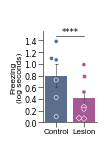

In [11]:
diff_bar_figsize = (18 * MM_TO_INCH, 30 * MM_TO_INCH)
print('Fig4i -- Freezing, Novel Conspecific')
ax, stats = one_condition_plot(novel, beh='FF', beh_label='Freezing', beh_units='log seconds', beh_regex_str='_', order=None, hue_order=['CON','EXP'], separate_x_by_group=True)
ax.figure.set_size_inches(diff_bar_figsize)
ax.set_title(' ')

# Remove legend, relabel groups (same as Fig4e/4g)
group_labels = {'CON': 'Control', 'EXP': 'Lesion'}
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_xticklabels(
    [group_labels.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
    fontsize=5.8, fontfamily='arial',
)
add_sig_bracket(ax, x1=0, x2=1, pval=stats['p_group_full'])
# plt.savefig('Fig4_i_novel_conspecific_freezing_with_sig.pdf', bbox_inches='tight')

### SuppFig. 7a and b: Locomotion results 

MixedLM Locomotion: Group: z=-1.33, P=0.1824; Cond: z=-2.45, P=0.0141; GroupByCond: z=1.37, P=0.1712
Group effect within NEC: z=0.60, P=0.5474
DROP -- MixedLM Locomotion: Group: z=-0.54, P=0.5861; Cond: z=-2.61, P=0.0091; GroupByCond: z=2.55, P=0.0107
DROP -- Group effect within NEC: z=2.81, P=0.0050
EXP vs. Ctrl & Drop -- MixedLM Locomotion: Group=0.5759511235137246, Cond=0.0013229874211987088, GroupByCond=0.007354434736296161
NECvsALN Locomotion: t(5)=-0.85, P=0.4351
DROP -- NECvsALN Locomotion: t(2)=-1.13, P=0.3768


C:\Users\psiok\AppData\Local\Temp\ipykernel_19500\845397588.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(


1.0811362671762492

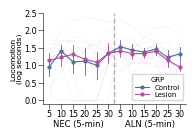

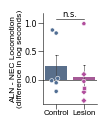

In [12]:
MM_TO_INCH = 1 / 25.4

timecourse_figsize = (47 * MM_TO_INCH, 30 * MM_TO_INCH)  # 48mm x 30mm -> (1.890, 1.181) inches
diff_bar_figsize = (18 * MM_TO_INCH, 30 * MM_TO_INCH)
ax1, ax2, diff_stats = nec_aln_plot_with_diff(
    nec30aln30_t1, beh='LO', beh_label='Locomotion', beh_units='log seconds',
    beh_regex_str='_', order=['NEC','A'], hue_order=['CON','EXP'],
    timecourse_figsize=timecourse_figsize, diff_figsize=diff_bar_figsize
)

# --- Same label updates as Fig4e/4g (post-processing, not inside
# nec_aln_plot_with_diff, since that function is also used by SFig2e) ---
group_labels = {'CON': 'Control', 'EXP': 'Lesion'}

# Panel a: relabel legend entries
if ax1.get_legend() is not None:
    for txt in ax1.get_legend().get_texts():
        txt.set_text(group_labels.get(txt.get_text(), txt.get_text()))

# Panel b: no legend, no "GRP" x-axis label, x-ticks relabeled,
# zero-difference reference line matching the axis linewidth (0.4)
if ax2.get_legend() is not None:
    ax2.get_legend().remove()
ax2.set_xlabel('')
ax2.set_xticklabels(
    [group_labels.get(t.get_text(), t.get_text()) for t in ax2.get_xticklabels()],
    fontsize=5.8, fontfamily='arial',
)
ax2.axhline(0, color='black', linewidth=0.4)
add_sig_bracket(ax2, x1=0, x2=1, pval=diff_stats['p_group_full'])

# ax1.set_title('NEC30-ALN30', fontsize=6, fontfamily='arial', pad=1)
# ax1.figure.savefig('SFig7_a_HIP_persistence_locomotion_timecourse.pdf', bbox_inches='tight', transparent=True)
# ax2.figure.savefig('SFig7_b_HIP_persistence_locomotion_diff_with_sig.pdf', bbox_inches='tight')

### SupFig 7c - Locomotion during social interaction

SFig7c -- Locomotion, Novel Conspecific


C:\Users\psiok\AppData\Local\Temp\ipykernel_19500\568282269.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  this_beh_df['Cond_num'] = this_beh_df['COND'].replace({'A': 1, 'N': 2, 'S': 3})
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmo

logFF: Group: z=0.28, P=0.7826
DROP -- logFF: Group: z=-0.28, P=0.7828
HIGH-QUALITY -- logFF: Group: z=-0.28, P=0.7776


C:\Users\psiok\AppData\Local\Temp\ipykernel_19500\4184950342.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


1.942700234716974

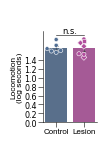

In [13]:
diff_bar_figsize = (18 * MM_TO_INCH, 30 * MM_TO_INCH)
print('SFig7c -- Locomotion, Novel Conspecific')
ax, stats = one_condition_plot(novel, beh='LO', beh_label='Locomotion', beh_units='log seconds', beh_regex_str='_', order=None, hue_order=['CON','EXP'], separate_x_by_group=True)
ax.figure.set_size_inches(diff_bar_figsize)
ax.set_title(' ')

group_labels = {'CON': 'Control', 'EXP': 'Lesion'}
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_xticklabels(
    [group_labels.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
    fontsize=5.8, fontfamily='arial',
)
add_sig_bracket(ax, x1=0, x2=1, pval=stats['p_group_full'])
# ax.figure.savefig('SFig7_c_social_interaction_locomotion_diff_with_sig.pdf', bbox_inches='tight')

### SFig 7d — Independent NEC-only assessment (uPET), pre & post lesion

SFig7d (pre) -- Freezing, NEC-only, before lesion
logFF: Group: z=-1.36, P=0.1742
DROP -- logFF: Group: z=-2.45, P=0.0143
HIGH-QUALITY -- logFF: Group: z=-2.58, P=0.0099


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\psiok\AppData\Local\Temp\ipykernel_19500\2522091891.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


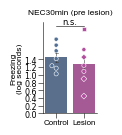

In [14]:
print('SFig7d (pre) -- Freezing, NEC-only, before lesion')
diff_bar_figsize = (18 * MM_TO_INCH, 30 * MM_TO_INCH)
upet_pre = upet.filter(regex='SUBJ|PAIR|GRP|.*_PRE')
upet_pre.columns = [s.replace('_PRE','') for s in upet_pre.columns]
ax, stats = one_condition_plot(upet_pre, beh='FF', beh_label='Freezing', beh_units='log seconds', beh_regex_str='', order=None, hue_order=['CON','EXP'], separate_x_by_group=True)
group_labels = {'CON': 'Control', 'EXP': 'Lesion'}
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_xticklabels(
    [group_labels.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
    fontsize=5.8, fontfamily='arial',
)
add_sig_bracket(ax, x1=0, x2=1, pval=stats['p_group_full'])
ax.set_title('NEC30min (pre lesion)', fontsize=6, fontfamily='arial', pad=6)
ax.figure.set_size_inches(diff_bar_figsize)
# plt.savefig('SFig7_d_prelesion_NEC_freezing_with_sig.pdf', bbox_inches='tight')


SFig7d (post) -- Freezing, NEC-only, after lesion


C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base

logFF: Group: z=-0.37, P=0.7092
DROP -- logFF: Group: z=0.73, P=0.4683
HIGH-QUALITY -- logFF: Group: z=0.77, P=0.4400


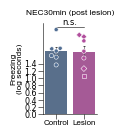

In [15]:
print('SFig7d (post) -- Freezing, NEC-only, after lesion')
upet_post = upet.filter(regex='SUBJ|PAIR|GRP|.*_POST')
upet_post.columns = [s.replace('_POST1','') for s in upet_post.columns]
ax, stats = one_condition_plot(upet_post, beh='FF', beh_label='Freezing', beh_units='log seconds', beh_regex_str='', order=None, hue_order=['CON','EXP'], separate_x_by_group=True)

group_labels = {'CON': 'Control', 'EXP': 'Lesion'}
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_xticklabels(
    [group_labels.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
    fontsize=5.8, fontfamily='arial',
)
add_sig_bracket(ax, x1=0, x2=1, pval=stats['p_group_full'])
ax.set_title('NEC30min (post lesion)', fontsize=6, fontfamily='arial', pad=6)
ax.figure.set_size_inches(diff_bar_figsize)
ax.figure.savefig(os.path.join(OUTPUT_DIR, 'SFig7_d_postlesion_NEC_freezing_with_sig.pdf'), bbox_inches='tight')

### SupFig 7e - Freezing in HIP (Second Exposure)

SFig7e -- Freezing, HIP-Persistence (T2, second exposure)
MixedLM Freezing: Group: z=-1.50, P=0.1341; Cond: z=0.78, P=0.4365; GroupByCond: z=1.84, P=0.0664
Group effect within NEC: z=1.10, P=0.2721
DROP -- MixedLM Freezing: Group: z=-3.24, P=0.0012; Cond: z=0.84, P=0.4026; GroupByCond: z=3.20, P=0.0014
DROP -- Group effect within NEC: z=1.10, P=0.2703
EXP vs. Ctrl & Drop -- MixedLM Freezing: Group=0.0007019072492729884, Cond=0.4945871699136495, GroupByCond=0.0005834386811135538
NECvsALN Freezing: t(4)=-3.03, P=0.0389
DROP -- NECvsALN Freezing: t(2)=-2.53, P=0.1274


C:\Users\psiok\AppData\Local\Temp\ipykernel_19500\1454961769.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(


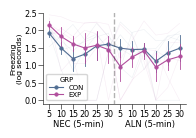

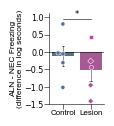

In [16]:
MM_TO_INCH = 1 / 25.4

timecourse_figsize = (47 * MM_TO_INCH, 30 * MM_TO_INCH)  # 48mm x 30mm -> (1.890, 1.181) inches
diff_bar_figsize = (18 * MM_TO_INCH, 30 * MM_TO_INCH)
print('SFig7e -- Freezing, HIP-Persistence (T2, second exposure)')
ax1, ax2, diff_stats = nec_aln_plot_with_diff(
    nec30aln30_t2, beh='FF', beh_label='Freezing', beh_units='log seconds',
    beh_regex_str='_', order=['NEC','A'], hue_order=['CON','EXP'],
    timecourse_figsize=timecourse_figsize, diff_figsize=diff_bar_figsize
)

# Same panel-g/SFig7b style: no legend, no "GRP" x-axis label, x-ticks
# relabeled, zero-difference reference line matching the axis linewidth (0.4)
group_labels = {'CON': 'Control', 'EXP': 'Lesion'}
if ax2.get_legend() is not None:
    ax2.get_legend().remove()
ax2.set_xlabel('')
ax2.set_xticklabels(
    [group_labels.get(t.get_text(), t.get_text()) for t in ax2.get_xticklabels()],
    fontsize=5.8, fontfamily='arial',
)
ax2.set_ylim(-1.5, 1)
ax2.set_yticks(np.arange(-1.5, 1 + 0.5, 0.5))
ax2.axhline(0, color='black', linewidth=0.4)
add_sig_bracket(ax2, x1=0, x2=1, pval=diff_stats['p_group_full'])

ax2.figure.savefig(os.path.join(OUTPUT_DIR, 'SFig7_e_HIP_persistence_freezing_diff_T2_with_sig.pdf'), bbox_inches='tight')